# Setup

In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from astropy import constants as const, units as u

In [2]:
import sys
sys.path.append('../')

In [3]:
from functions import epsilon

In [4]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # <--- default: dejavusans

/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_49231/3027973147.py:113: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x12f777d10>' will be ignored
  ax0contourf.set_rasterized(True)
/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_49231/3027973147.py:114: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x13e85c9e0>' will be ignored
  ax1contourf.set_rasterized(True)


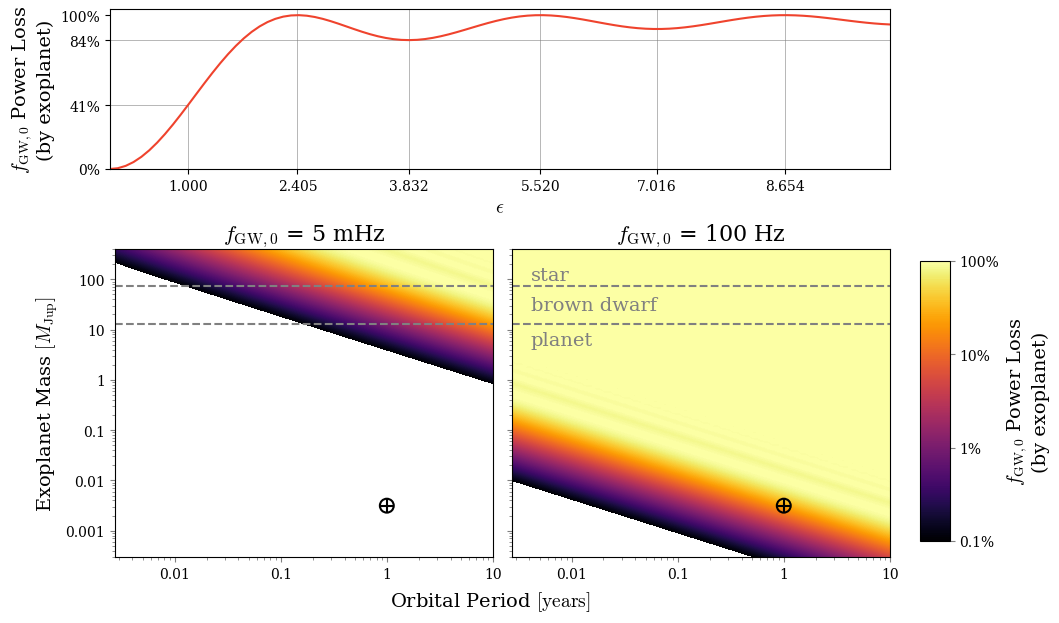

In [17]:
fig, ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05)#, hspace=0)
ax[0].set_xscale('log'), ax[0].set_yscale('log')


i = np.pi/2

Pvals = np.logspace(np.log10(1*u.day.to(u.year)),np.log10(10),100)  # units: [years]
Mvals = np.logspace(np.log10(0.0003),np.log10(400),100)             # units: [Jup mass]
PPvals, MMvals = np.meshgrid(Pvals, Mvals)

level_exp = np.linspace(-1, 2, 400)
levels    = np.power(10, level_exp)

# 1st panel  ----------------------------------------------------------------------------------------------------------------------------
M_sys = 1.5 * const.M_sun.value
f_gw0 = 5e-3

epsvals = epsilon( MMvals*const.M_jup.value, i, 1/(PPvals*u.year.to(u.s)), f_gw0, M_sys )
RelDiff = 1-sp.jv(0,epsvals)**2
PercentDiff = RelDiff*100

ax0contourf = ax[0].contourf(PPvals, MMvals, PercentDiff, levels, norm=colors.LogNorm(), cmap='inferno')
ax[0].set_title(r'$f_\mathrm{{GW,0}}$ = {0:0.0f} mHz'.format(f_gw0/1e-3), fontsize=16)

# # Top x-axis
# ax0 = ax[0].secondary_xaxis('top')
# ax0.tick_params(direction="out")
# ax0.set_xticks([1*u.day.to(u.year), 4*u.week.to(u.year)]), ax0.set_xticklabels(['1 day', '4 weeks'])
# ax0.minorticks_off()



# 2nd panel  ----------------------------------------------------------------------------------------------------------------------------
M_sys = 1.5 * const.M_sun.value
f_gw0 = 1e2

epsvals = epsilon( (MMvals)*const.M_jup.value, i, 1/((PPvals)*u.year.to(u.s)), f_gw0, M_sys )
RelDiff = 1-sp.jv(0,epsvals)**2
PercentDiff = RelDiff*100

ax1contourf = ax[1].contourf(PPvals, MMvals, PercentDiff, levels, norm=colors.LogNorm(), cmap='inferno')
ax[1].set_title(r'$f_\mathrm{{GW,0}}$ = {0:0.0f} Hz'.format(f_gw0), fontsize=16)


# Colorbar  ----------------------------------------------------------------------------------------------------------------------------
cbar_ax = fig.add_axes([0.93, 0.15, 0.03, 0.7])
cbar = fig.colorbar(ax1contourf, cax=cbar_ax, ticks=np.array([0.1,1,10,100]))
cbar.set_label(r'$f_\mathrm{GW,0}$ Power Loss'+'\n'+r'(by exoplanet)', fontsize=14)#, labelpad=20)
cbar.ax.tick_params(color='grey')
cbar.ax.set_yticklabels(['0.1%', '1%', '10%', '100%'])


# Reference Planets  -------------------------------------------------------------------------------------------------------------------
for i in range(0,len(ax)):
    # -- Jupiter
    # ax[i].scatter(11.86,1, marker='o')
    # -- Earth
    ax[i].scatter(1,1*u.M_earth.to(u.M_jup), marker='o', facecolor='none', linewidths=1.5, edgecolor='k', s=100)  
    ax[i].scatter(1,1*u.M_earth.to(u.M_jup), marker='+', color='k', s=100)


# Top Plot  ----------------------------------------------------------------------------------------------------------------------------
axtop = fig.add_axes([0.12, 1.08, 0.78, 0.4])

xmax = 10
eps  = np.linspace(0,xmax,100)
bessel_solns = [2.405, 3.832, 5.520, 7.016, 8.654, 10.173, 11.792, 13.324]

# axtop.plot((0, 3.832), (1-sp.jv(0,3.832)**2, 1-sp.jv(0,3.832)**2), color='gray', linestyle='--', alpha=0.8, linewidth=0.5)
axtop.plot((0, 1), (1-sp.jv(0,1)**2, 1-sp.jv(0,1)**2), color='gray', linestyle='-', alpha=0.8, linewidth=0.5)
axtop.plot((1, 1), (1-sp.jv(0,1)**2, 0),               color='gray', linestyle='-', alpha=0.8, linewidth=0.5)

axtop.plot(eps, 1-sp.jv(0,eps)**2, color='#ef432d')

axtop.set_xlim([0,xmax]); axtop.set_ylim([0,1.04]);
axtop.set_xticks(np.asarray(bessel_solns+[1])[np.asarray(bessel_solns+[1]) < xmax], [f'{i:0.3f}' for i in np.asarray(bessel_solns+[1])[np.asarray(bessel_solns+[1]) < xmax]])#, rotation=55)
# axtop.grid(axis='x')
for bs in np.asarray(bessel_solns)[np.asarray(bessel_solns) < xmax]:
    axtop.axvline(bs, color='gray', alpha=0.8, linewidth=0.5, zorder=-1)
axtop.axhline(1-sp.jv(0,3.832)**2, color='gray', alpha=0.8, linewidth=0.5, linestyle='-', zorder=-1)

# Text and horizontal lines ---------------------------------------------------------------------------------------------------------------
for i in range(0,len(ax)):
    ax[i].axhline(13, linestyle='--', color='gray')
    ax[i].axhline(72, linestyle='--', color='gray')
    if i == 1:
        ax[i].text(0.05,13-8,  'planet',      fontsize=14, color='gray', transform=ax[i].get_yaxis_transform())
        ax[i].text(0.05,13+11, 'brown dwarf', fontsize=14, color='gray', transform=ax[i].get_yaxis_transform())
        ax[i].text(0.05,72+26, 'star',        fontsize=14, color='gray', transform=ax[i].get_yaxis_transform())

# # Text and vertical lines ---------------------------------------------------------------------------------------------------------------
# ax[0].axvline(4/2, linestyle='--', color='gray')
# ax[1].axvline(0.8333/2, linestyle='--', color='gray')

# Axes labels and titles formatting  ------------------------------------------------------------------------------------------------------
ax[0].set_xticks([1e-2,1e-1,1,1e1]), ax[0].set_xticklabels(['0.01', '0.1', '1', '10'])
# ax[0].set_xticks([1e-2,1e-1,1,1e1,1*u.day.to(u.year)]), ax[0].set_xticklabels(['0.01', '0.1', '1', '10', '1 day'])
# ax[0].set_xticks([1e-2,1*u.day.to(u.year),4*u.week.to(u.year),1e-1,1,1e1]), ax[0].set_xticklabels(['0.01', '1 day', '4 weeks', '0.1', '1', '10'])
fig.supxlabel(r'Orbital Period $[\text{years}]$', y=-0.03, fontsize=14)

# ax[0].set_ylim(bottom=0.6), ax[0].set_yticks([1,10,100]), ax[0].set_yticklabels(['1','10','100'])
ax[0].set_yticks([1e-3,1e-2,1e-1,1,1e1,1e2]), ax[0].set_yticklabels(['0.001','0.01', '0.1', '1', '10', '100']) #$\\mathdefault{10^{-3}}$
ax[0].set_ylabel(r'Exoplanet Mass $[M_\text{Jup}]$', fontsize=14)
ax[0].tick_params(axis='both', which='both', color='gray'), ax[1].tick_params(axis='both', which='both', color='gray')

axtop.set_yticks([0,1-sp.jv(0,1)**2,1-sp.jv(0,3.832)**2,1]), axtop.set_yticklabels(['0%', '{0:0.0f}%'.format((1-sp.jv(0,1)**2)*100), '{0:0.0f}%'.format((1-sp.jv(0,3.832)**2)*100), '100%'])
axtop.set_xlabel(r'$\epsilon$', fontsize=14); 
axtop.set_ylabel(r'$f_\mathrm{GW,0}$ Power Loss'+'\n'+r'(by exoplanet)', fontsize=14);

# Rasterize the contourfs, to reduce the PDF file size significantly!
# NOTE: it may output a "UserWarning" - I don't know why, but this line still works (verified by opening the file in Inkscape)
ax0contourf.set_rasterized(True)
ax1contourf.set_rasterized(True)

plt.show()
# plt.savefig('./PSD_RelDiff.pdf', bbox_inches='tight')